In [130]:
import ollama 
import os
from tqdm import tqdm
import json
import signal
import argparse
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import copy
import sys
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

#from  utilities import *

In [131]:
sys.argv = [
    'notebook',  
    '--modelname', 'llama3.2-vision:90b',
    '--data', 'gully',
    '--data_path','/home/data/',
    "--data_samples", 'train.jsonl',
    "--subset", 'train',
    '--results_dir', '/mnt/jacket/WACV-2025-Workshop-ViGIR/results/proposed',
    '--timeout', '20',
    '--model_unloading'
]

In [132]:
parser = argparse.ArgumentParser(description="A script to run V-LLMs on different image classification datasets")

In [133]:
# set up the argument parser
parser.add_argument("--modelname", type=str, required=True, help="The name of the V-LLM model")
parser.add_argument("--data", type=str, required=True, help="Dataset name")
parser.add_argument("--data_path", type=str, required=True, help="Path to the image data dir")
parser.add_argument("--data_samples", type=str, required=True, help="Name of the samples to run on")
parser.add_argument("--subset", type=str, required=True, help="train, test or validation set")
parser.add_argument("--results_dir", type=str, required=True, help="Folder name to save results")
parser.add_argument("--timeout", type=int, default=40, help="time out duration to skip one sample")
parser.add_argument("--model_unloading", action="store_true", help="Enables unloading mode. Every 100 sampels it unloades the model from the GPU to avoid carshing.")


args = parser.parse_args()

In [134]:
# Load test set:
#file_path = 'Testing_Set.json'
file_path = 'Validation_Set.json'
with open(file_path, 'r') as file:
    data = json.load(file)

print('Number of Annotated GT Images: ', len(data.keys()))
data_keys_test = list(data.keys())
print('Number of Annotated GT Images (List): ', len(data_keys_test))

Number of Annotated GT Images:  310
Number of Annotated GT Images (List):  310


In [135]:
# Load results from a specifc model
#filename = 'valid_'+args.modelname+'.json'
filename = 'valid_llama3_90b.json'
with open((os.path.join(args.results_dir, filename)), 'r') as file:
    result_data = json.load(file)

print('Results from: ', args.modelname)
print('Number of Images: ', len(result_data.keys()))
result_data_keys = list(result_data.keys())
print('Number of Images (List): ', len(result_data_keys))

Results from:  llama3.2-vision:90b
Number of Images:  310
Number of Images (List):  310


In [136]:
num_questions = 15
histogram_gully = {i: 0 for i in range(num_questions)}
histogram_not_gully = {i: 0 for i in range(num_questions)}
no_histogram_gully = {i: 0 for i in range(num_questions)}
no_histogram_not_gully = {i: 0 for i in range(num_questions)}

In [137]:
data_gully = {}
data_not_gully = {}
for key, item in data.items():
    if item['label'] == '4':
        data_gully[key] = item['label']
    if item['label'] == '0':
        data_not_gully[key] = item['label']

In [138]:
print(len(data_gully))
print(len(data_not_gully))

177
133


In [139]:
for key, item in result_data.items():
    #print(key)
    #print(item)
    #print(len(item))
    for idx in range(len(item)):
        #print(item[idx][0]['label'])
        #print(item[idx][-1].split('.')[0])
        if item[idx][0]['label'] == '4' and item[idx][-1].split('.')[0] == 'Yes':
            histogram_gully[idx] += 1

        if item[idx][0]['label'] == '0' and item[idx][-1].split('.')[0] == 'Yes':
            histogram_not_gully[idx] += 1


        if item[idx][0]['label'] == '4' and item[idx][-1].split('.')[0] == 'No':
            no_histogram_gully[idx] += 1

        if item[idx][0]['label'] == '0' and item[idx][-1].split('.')[0] == 'No':
            no_histogram_not_gully[idx] += 1


In [140]:
histogram_gully_values = np.array(list(histogram_gully.values()))
histogram_not_gully_values = np.array(list(histogram_not_gully.values()))
no_histogram_gully_values = np.array(list(no_histogram_gully.values()))
no_histogram_not_gully_values = np.array(list(no_histogram_not_gully.values()))

In [141]:
print(histogram_gully_values)
print(histogram_not_gully_values)
print(no_histogram_gully_values)
print(no_histogram_not_gully_values)

[  9   0  35   0  34 110 119  50   0   0  93  12   0   5   0]
[ 6  0  6  0 10 39 37 33  0  0 69  2  0  1  0]
[168 177 142 177 143  67  58 127 177 177  84 165 177 172 177]
[127 133 127 133 123  94  96 100 133 133  64 131 133 132 133]


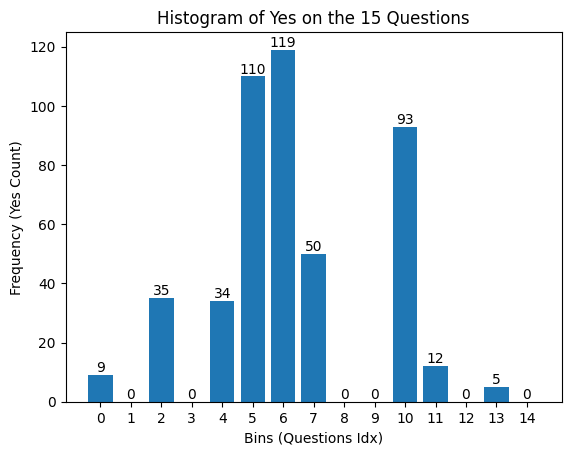

<Figure size 640x480 with 0 Axes>

In [151]:
fig, ax = plt.subplots()
values = np.linspace(0, num_questions-1, num_questions)
bars = ax.bar(values, histogram_gully_values)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval, str(yval), va='bottom', ha='center')


plt.xticks(np.arange(num_questions))
plt.xlabel('Bins (Questions Idx)')
plt.ylabel('Frequency (Yes Count)')
plt.title('Histogram of Yes on the 15 Questions')
plt.show()
plt.savefig("histogram_yes_when_gully.pdf", format="pdf")


#plt.hist(histogram_gully_values, bins=15, color='skyblue', edgecolor='black')



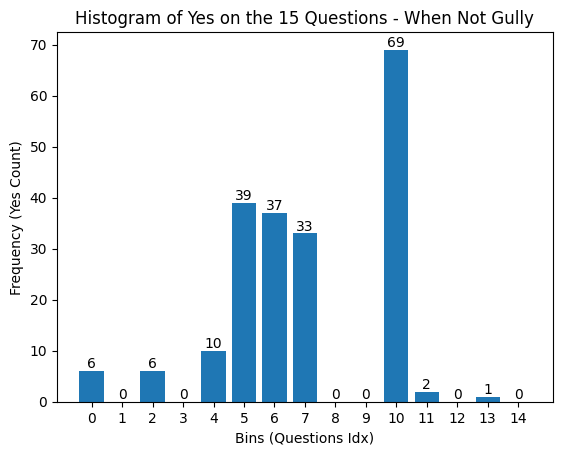

In [152]:
fig, ax = plt.subplots()
values = np.linspace(0, num_questions-1, num_questions)
bars = ax.bar(values, histogram_not_gully_values)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval, str(yval), va='bottom', ha='center')


plt.xticks(np.arange(num_questions))
plt.xlabel('Bins (Questions Idx)')
plt.ylabel('Frequency (Yes Count)')
plt.title('Histogram of Yes on the 15 Questions - When Not Gully')
plt.savefig("histogram_yes_when_not_gully.pdf")
plt.show()


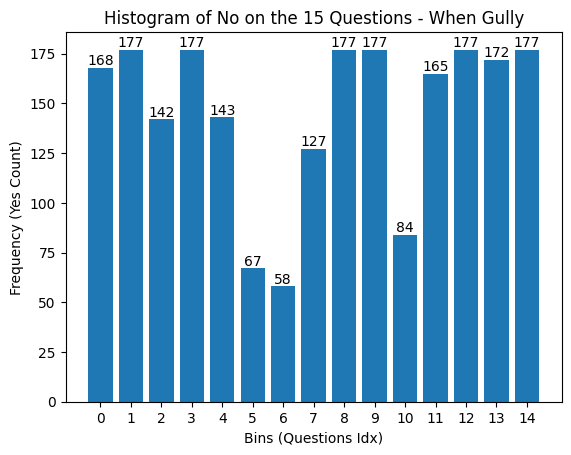

In [153]:
fig, ax = plt.subplots()
values = np.linspace(0, num_questions-1, num_questions)
bars = ax.bar(values, no_histogram_gully_values)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval, str(yval), va='bottom', ha='center')


plt.xticks(np.arange(num_questions))
plt.xlabel('Bins (Questions Idx)')
plt.ylabel('Frequency (Yes Count)')
plt.title('Histogram of No on the 15 Questions - When Gully')
plt.savefig("histogram_no_when_gully.pdf")
plt.show()



#plt.hist(histogram_gully_values, bins=15, color='skyblue', edgecolor='black')



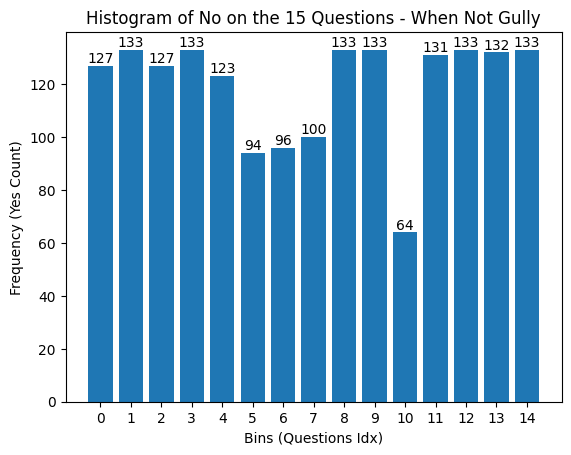

In [154]:
fig, ax = plt.subplots()
values = np.linspace(0, num_questions-1, num_questions)
bars = ax.bar(values, no_histogram_not_gully_values)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval, str(yval), va='bottom', ha='center')


plt.xticks(np.arange(num_questions))
plt.xlabel('Bins (Questions Idx)')
plt.ylabel('Frequency (Yes Count)')
plt.title('Histogram of No on the 15 Questions - When Not Gully')
plt.savefig("histogram_no_when_not_gully.pdf")
plt.show()
